# Тестирование гипотез для препроцессинга

In [ ]:
import os 

import matplotlib

In [10]:
import mne 
mne.viz.set_browser_backend('qt')

Using qt as 2D backend.


In [26]:
# открытие файла с n3-интервалом
# data/n3_intervals/sub_**/....edf

interval = mne.io.read_raw_edf('/Users/glytov_ivan/Documents/СНК/СНК ВМ/hfo_detectors_comparison_project/EEG_Detectors_test/data/n3_intervals/sub_01/sub-01_ses-01_task-hfo_run-01_eeg.edf', 
preload=True)

Extracting EDF parameters from /Users/glytov_ivan/Documents/СНК/СНК ВМ/hfo_detectors_comparison_project/EEG_Detectors_test/data/n3_intervals/sub_01/sub-01_ses-01_task-hfo_run-01_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 599999  =      0.000 ...   300.000 secs...


In [27]:
interval.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1-Fp2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fp2-F8, F8-T4, T4-T6, ...
 chs: 52 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 1000.0 Hz
 meas_date: 2021-03-01 17:38:22 UTC
 nchan: 52
 projs: []
 sfreq: 2000.0 Hz
 subject_info: <subject_info | his_id: <no>
>

In [32]:
# hyperparameters

SAMPLING_RATE = interval.info['sfreq']

LOW_FREQS = 80
HIGH_FREQS = 500

In [ ]:
# оценка bad_channels

BAD_CHANNELS = interval.info['bads']



In [ ]:
# ремнотаж - уже сделан
...

In [30]:
# notch-filters

interval.notch_filter(freqs=50)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 13201 samples (6.601 s)



<RawEDF | sub-01_ses-01_task-hfo_run-01_eeg.edf, 52 x 600000 (300.0 s), ~238.1 MiB, data loaded>

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/var/folders/4z/21mgxjbx2_v3_qj5c6zd45zw0000gn/T/ipykernel_22732/3720954954.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  interval.plot_psd()
/Users/glytov_ivan/Documents/СНК/СНК ВМ/hfo_detectors_comparison_project/venv/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


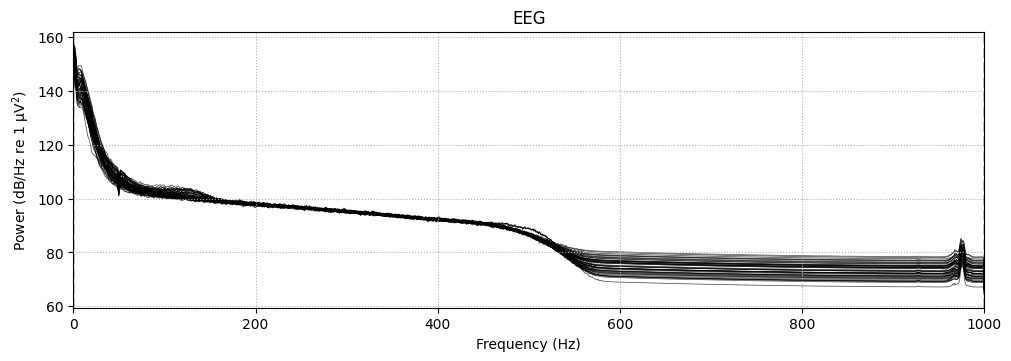

In [31]:
# psd 

interval.plot_psd()

In [33]:
# полосовая фильтрация

interval.filter(l_freq=LOW_FREQS, h_freq=HIGH_FREQS)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 80 - 5e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 80.00
- Lower transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 70.00 Hz)
- Upper passband edge: 500.00 Hz
- Upper transition bandwidth: 125.00 Hz (-6 dB cutoff frequency: 562.50 Hz)
- Filter length: 331 samples (0.166 s)



<RawEDF | sub-01_ses-01_task-hfo_run-01_eeg.edf, 52 x 600000 (300.0 s), ~238.1 MiB, data loaded>

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/var/folders/4z/21mgxjbx2_v3_qj5c6zd45zw0000gn/T/ipykernel_22732/3720954954.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  interval.plot_psd()
/Users/glytov_ivan/Documents/СНК/СНК ВМ/hfo_detectors_comparison_project/venv/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


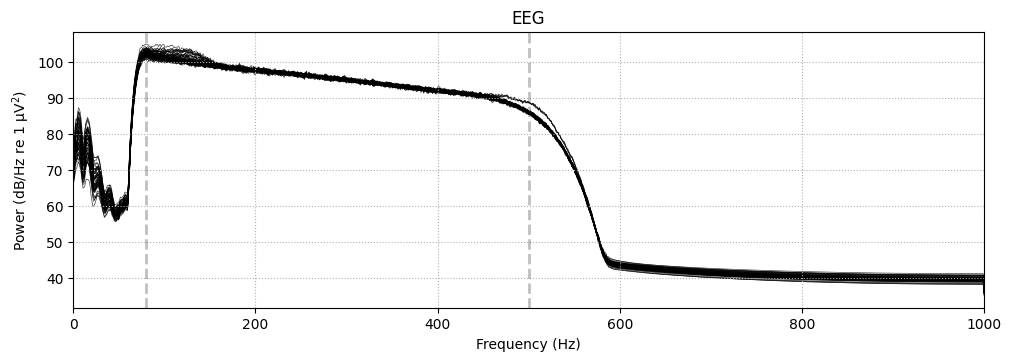

In [34]:
# psd 

interval.plot_psd()

In [35]:
interval.plot()